In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from mplsoccer import Pitch, Sbopen, VerticalPitch
from matplotlib.patches import Patch

# 1. Load the Dataset

In [2]:
parser = Sbopen()
df, relalated, freeze, tactics = parser.event(3923881)
# A dataframe for passes without throw-ins
passes = df.loc[df['type_name'] == 'Pass'].loc[df['sub_type_name'] != 'Throw-in'].set_index('id')

# 2. Making the Pass Map using Iterative Solution 

Draw the pitch and iterate through the passes. 
Check if a pass was mad by Kessie, if so, take the starting coordinates of a pass and plot a circle. 
Then substract the coordinates begining of the pass from the end of passes in order to draw the pass arrow:

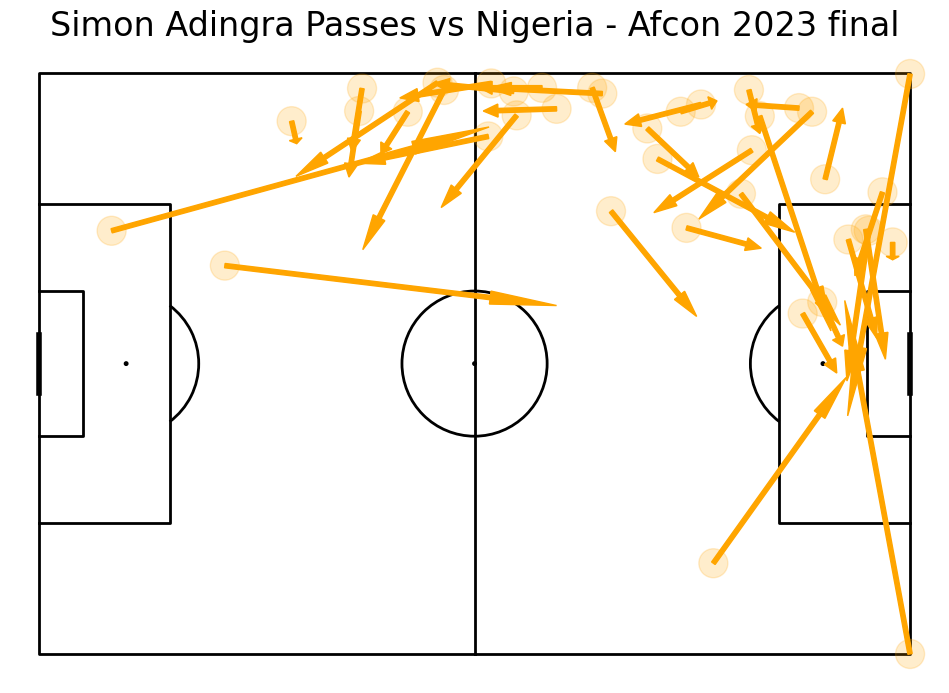

In [3]:
# draw the pitch 
pitch = Pitch(line_color = "black")
fig, ax = pitch.draw(figsize=(10, 7))

for i, thepass in passes.iterrows():
    # if the pass was made by Kessie 
    if thepass['player_name'] == 'Simon Adingra':
        x = thepass['x']
        y = thepass['y']

        # plot the circle 
        pass_circle = plt.Circle((x,y), 2, color = "orange")
        pass_circle.set_alpha(.2)
        ax.add_patch(pass_circle)
        
        dx = thepass['end_x'] - x
        dy = thepass['end_y'] - y

        # plot arrow
        pass_arrow = plt.Arrow(x,y,dx,dy,width=3, color="orange")
        ax.add_patch(pass_arrow)

ax.set_title("Simon Adingra Passes vs Nigeria - Afcon 2023 final", fontsize = 24)
plt.show()


# 2.1 Making the Pass Map Using mplsoccer Functions

Filter out passes made by Bassey. Take only the columns needed to plot passes - coordinates of start and end of a pass. 
Draw the pitch and use arrow method to plot the passes. 
Using scatter method, draw circles where the pass started, filter the dataset to complete passes for Calvin Bassey Ughelumba:

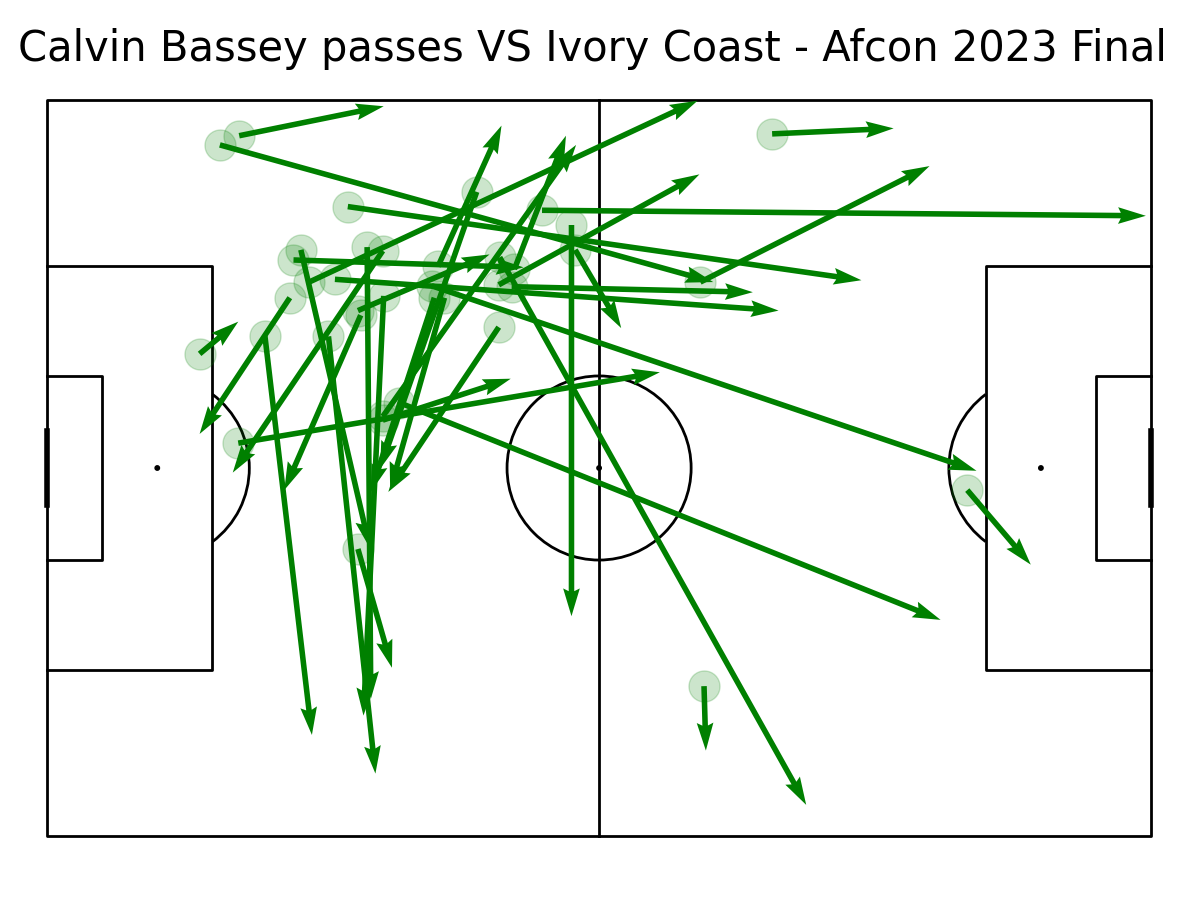

In [4]:
mask_bassey = (df.type_name == 'Pass') & (df.player_name == "Calvin Bassey Ughelumba")
df_pass = df.loc[mask_bassey, ['x', 'y', 'end_x', 'end_y']]

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.arrows(df_pass.x, df_pass.y,
            df_pass.end_x, df_pass.end_y, color = "green", ax=ax['pitch'])
pitch.scatter(df_pass.x, df_pass.y, alpha = 0.2, s = 500, color = "green", ax=ax['pitch'])
fig.suptitle("Calvin Bassey passes VS Ivory Coast - Afcon 2023 Final ", fontsize = 30)
plt.show()

# 2.3 Multiple Pass Maps on a Single Figure 

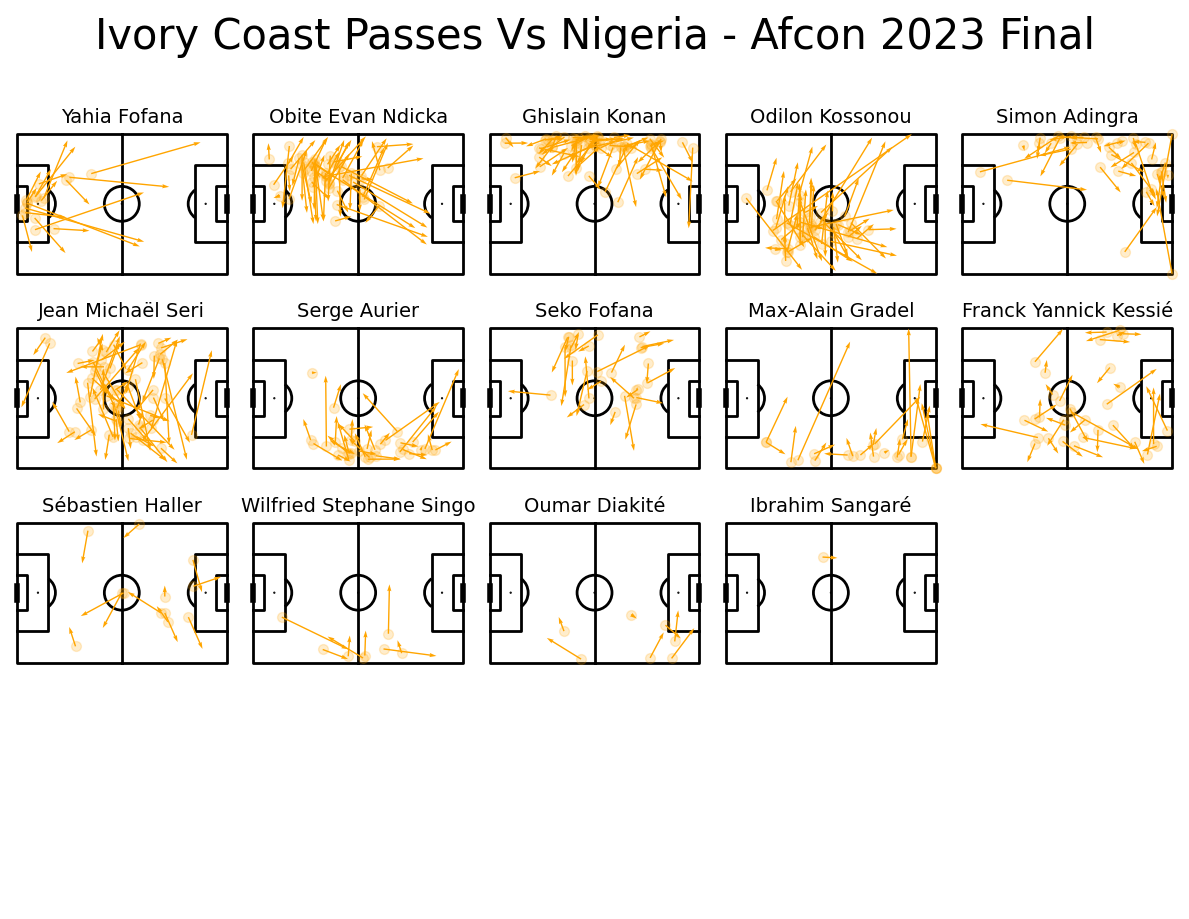

In [5]:
#prepare the dataframe of passes by Ivory Coast that were no-throw ins
mask_ivory_coast = (df.type_name == 'Pass') & (df.team_name == "Côte d'Ivoire") & (df.sub_type_name != "Throw-in")
df_passes = df.loc[mask_ivory_coast, ['x', 'y', 'end_x', 'end_y', 'player_name']]

#get the list of all players who made a pass
names = df_passes['player_name'].unique()
#draw 4x5 grid (20 pitches total to accommodate up to 16 players + 5 subs = potential 21, but we'll use what we need)

pitch = Pitch(line_color='black', pad_top=20)
fig, axs = pitch.grid(ncols = 5, nrows = 4, grid_height=0.85, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0.04, endnote_space=0.01)

#for each player
for name, ax in zip(names, axs['pitch'].flat[:len(names)]):
    #put player name over the plot
    ax.text(60, -10, name,
            ha='center', va='center', fontsize=14)
    #take only passes by this player
    player_df = df_passes.loc[df_passes["player_name"] == name]
    #scatter
    pitch.scatter(player_df.x, player_df.y, alpha = 0.2, s = 50, color = "orange", ax=ax)
    #plot arrow
    pitch.arrows(player_df.x, player_df.y,
            player_df.end_x, player_df.end_y, color = "orange", ax=ax, width=1)
    
# remove the unused pitches 
for ax in axs['pitch'].flat[len(names):]:
    ax.remove()
# set title 
axs['title'].text(0.5, 0.5, 'Ivory Coast Passes Vs Nigeria - Afcon 2023 Final', ha='center', va='center', fontsize=30)
plt.show()